In [116]:
import cv2 as cv
import numpy as np
import os
import matplotlib.pyplot as plt


In [20]:
sample_img_name = "image_512.jpg"
folder = "data/image_folder"

img_path = os.path.join(folder, sample_img_name)
img = cv.imread(img_path)

In [21]:
print(img_path)

data/image_folder\image_512.jpg


In [22]:
print(img.shape)

(360, 640, 3)


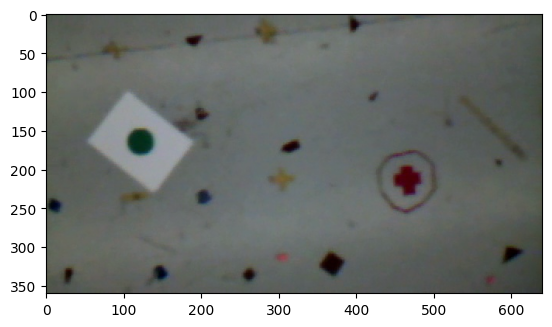

In [23]:
plt.imshow(img)

In [25]:
img_gray = cv.cvtColor(img, cv.COLOR_RGB2GRAY)

In [26]:
print(img_gray.shape)

(360, 640)


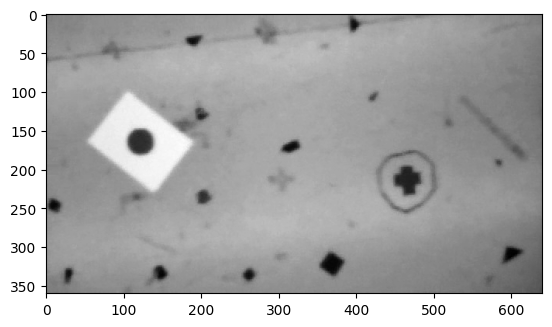

In [27]:
plt.imshow(img_gray, cmap='gray')

In [29]:
blurred = cv.GaussianBlur(img_gray, (3, 3), 0)
filtered_LoG = cv.Laplacian(blurred, cv.CV_16S, ksize=3)

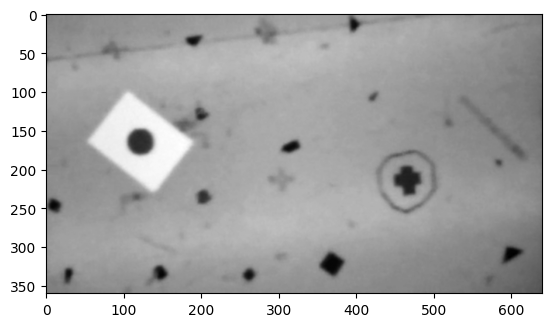

In [30]:
plt.imshow(blurred, cmap='gray')

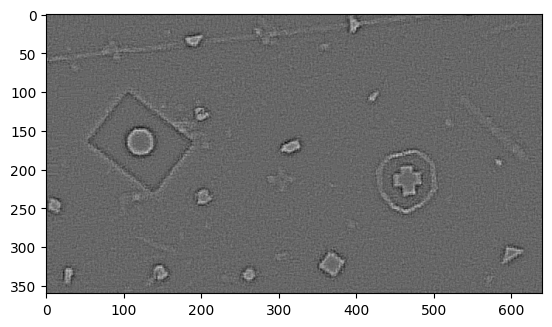

In [31]:
plt.imshow(filtered_LoG, cmap='gray')

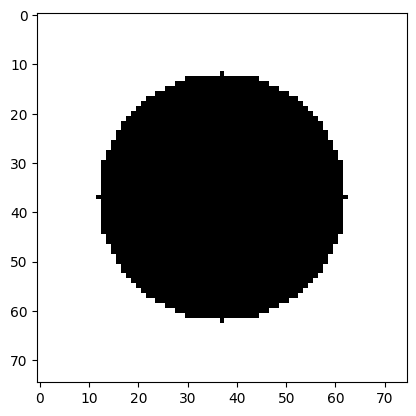

In [87]:
blank = np.ones((75,75), np.float64)
# cv.circle(	img, center, radius, color[, thickness[, lineType[, shift]]]	) -> 	img
circle_template = cv.circle(blank,(37,37),25 , 0, -1)
plt.imshow(circle_template, cmap='gray')

In [88]:
#dst = cv.filter2D(src, ddepth, kernel, anchor=(-1, -1), delta=0, borderType=cv.BORDER_DEFAULT)
blurred_float = blurred/255.0
test_filtered_img = cv.filter2D(blurred_float, -1, circle_template, borderType=cv.BORDER_DEFAULT)

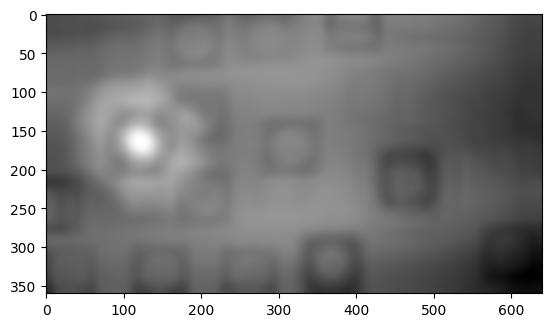

In [104]:
filtered_max = np.max(test_filtered_img.flatten())
filtered_min = np.min(test_filtered_img.flatten())
img_range = filtered_max - filtered_min
test_filtered_img = (test_filtered_img - filtered_min)/img_range
plt.imshow(test_filtered_img, cmap='gray')


ret= 200.0


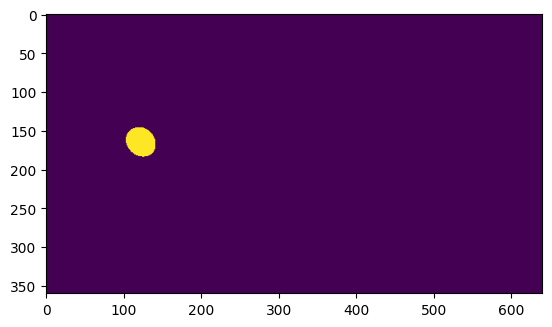

In [114]:
ret,filtered_thresholded = cv.threshold((test_filtered_img*255).astype(np.uint8),200,255,cv.THRESH_BINARY)
plt.imshow(filtered_thresholded)
print("ret=",ret)

In [78]:
np.max(blurred.flatten())

np.float64(0.6431372549019608)

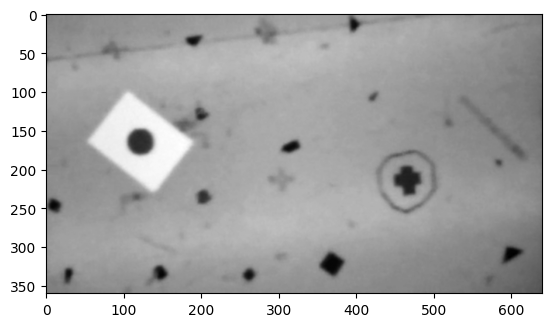

In [57]:
plt.imshow(blurred, cmap='gray')

In [118]:
# Apply template Matching
method = cv.TM_CCOEFF
res = cv.matchTemplate(blurred,circle_template,method)
min_val, max_val, min_loc, max_loc = cv.minMaxLoc(res)

# If the method is TM_SQDIFF or TM_SQDIFF_NORMED, take minimum
if method in [cv.TM_SQDIFF, cv.TM_SQDIFF_NORMED]:
    top_left = min_loc
else:
    top_left = max_loc
bottom_right = (top_left[0] + w, top_left[1] + h)

cv.rectangle(blurred,top_left, bottom_right, 255, 2)
plt.imshow(blurred, cmap='gray')

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\templmatch.cpp:1168: error: (-215:Assertion failed) (depth == CV_8U || depth == CV_32F) && type == _templ.type() && _img.dims() <= 2 in function 'cv::matchTemplate'


In [119]:
blurred.shape, circle_template.shape

((360, 640), (75, 75))

In [125]:
img_new = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
blank_new = np.ones((75,75,3), np.float64)
circle_template = cv.circle(blank,(37,37),25 , (0,0,0), -1)

res = cv.matchTemplate(img_new,circle_template,method)

img_new.shape

error: OpenCV(4.13.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\templmatch.cpp:1168: error: (-215:Assertion failed) (depth == CV_8U || depth == CV_32F) && type == _templ.type() && _img.dims() <= 2 in function 'cv::matchTemplate'


In [123]:
circle_template

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], shape=(75, 75))